In [2]:
from scipy.io import loadmat

mat_data = loadmat('E:\\Voltron2_part1\\Voltron_Cell1\\amp_data.mat')
print(mat_data.keys())
print(mat_data['dt'])

dict_keys(['__header__', '__version__', '__globals__', 'AOut', 'amp_data', 'dt', 'ncol', 'nrow'])
[[0.00100367]]


Using sigma=7.93 frames for Gaussian LP at cutoff=20 Hz


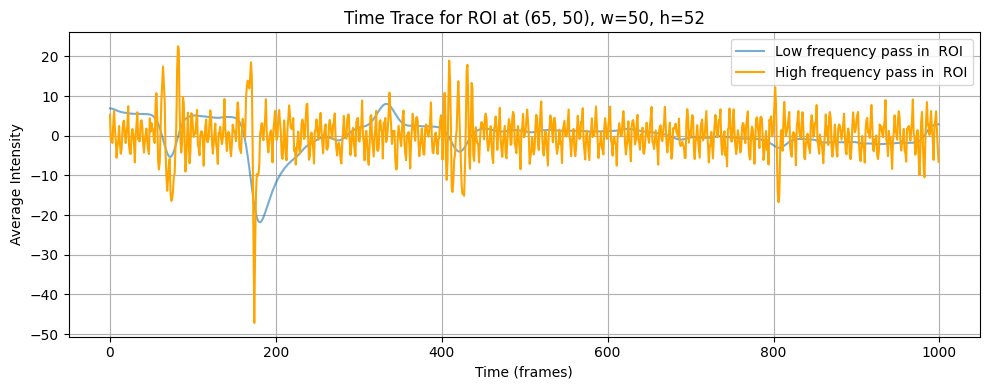

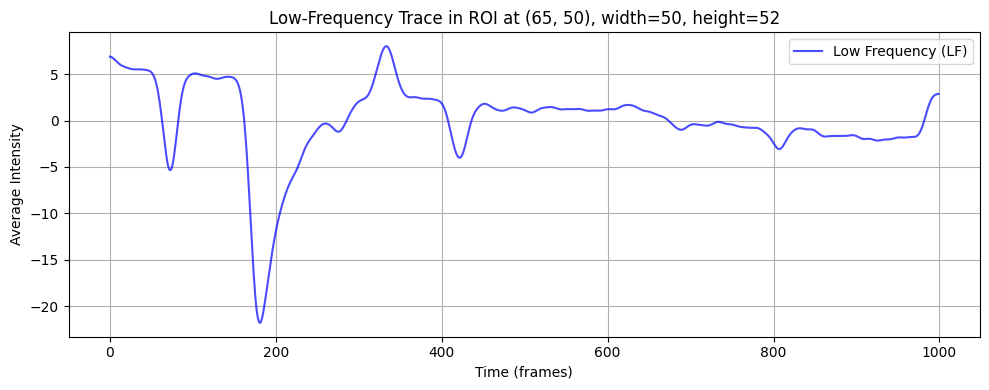

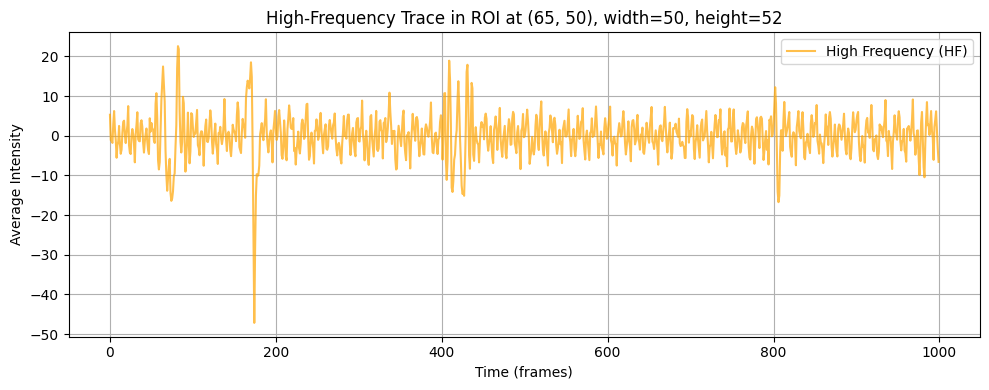

In [12]:
import torch
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
import tifffile

base_path_noisy = "E:\\Voltron2_part1\\Voltron_Cell1"

tif_file_noisy = next((f for f in os.listdir(base_path_noisy) if f.endswith(".tif")), None)

tif_path_noisy = os.path.join(base_path_noisy, tif_file_noisy)

# Read TIFF file
vol_data_noisy = tifffile.imread(tif_path_noisy)  # shape: (T, H, W) or (H, W)

vol_data_noisy = vol_data_noisy[800:1800]

# Your video tensor: (T, H, W)
video_np = vol_data_noisy.astype(np.float32)

# Sampling rate
fs = 996  # Hz

# Choose a cutoff frequency for low-pass filter (e.g., 20 Hz for background)
cutoff_hz = 20

# Convert to sigma (standard deviation) for Gaussian in units of frames
# f_c ≈ fs / (2π * σ) → σ ≈ fs / (2π * f_c)
sigma = fs / (2 * np.pi * cutoff_hz)

print(f"Using sigma={sigma:.2f} frames for Gaussian LP at cutoff={cutoff_hz} Hz")

# Apply Gaussian low-pass filter along time axis for each pixel
low_freq = gaussian_filter1d(video_np, sigma=sigma, axis=0, mode='reflect')

# High-frequency = original - low-frequency
high_freq = video_np - low_freq

# Convert back to torch tensors
low_freq_tensor = torch.tensor(low_freq, dtype=torch.float32)
high_freq_tensor = torch.tensor(high_freq, dtype=torch.float32)

x, y = 65, 50      # top-left corner (column, row)
width, height = 50, 52

lf_patch = low_freq_tensor[:, y:y+height, x:x+width]
hf_patch = high_freq_tensor[:, y:y+height, x:x+width]

lf_patch_trace = lf_patch.mean(dim=(1,2))
hf_patch_trace = hf_patch.mean(dim=(1,2))

lf_patch_trace -= lf_patch_trace.mean()
hf_patch_trace -= hf_patch_trace.mean()

plt.figure(figsize=(10, 4))
plt.plot(lf_patch_trace, label='Low frequency pass in  ROI', alpha=0.6)
plt.plot(hf_patch_trace, label='High frequency pass in  ROI', color='orange')
plt.xlabel("Time (frames)")
plt.ylabel("Average Intensity")
plt.title(f"Time Trace for ROI at ({x}, {y}), w={width}, h={height}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Low-Frequency Trace Plot
plt.figure(figsize=(10, 4))
plt.plot(lf_patch_trace, label='Low Frequency (LF)', color='blue', alpha=0.7)
plt.xlabel("Time (frames)")
plt.ylabel("Average Intensity")
plt.title(f"Low-Frequency Trace in ROI at ({x}, {y}), width={width}, height={height}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# High-Frequency Trace Plot
plt.figure(figsize=(10, 4))
plt.plot(hf_patch_trace, label='High Frequency (HF)', color='orange', alpha=0.7)
plt.xlabel("Time (frames)")
plt.ylabel("Average Intensity")
plt.title(f"High-Frequency Trace in ROI at ({x}, {y}), width={width}, height={height}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

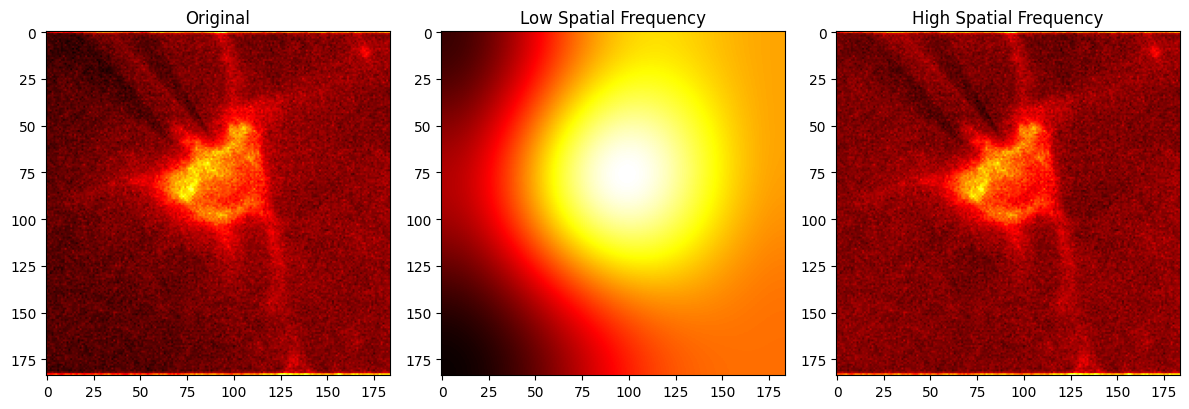

In [11]:
import torch
import numpy as np
from scipy.ndimage import gaussian_filter
import tifffile
import os

# --- Load your TIFF video ---
base_path = "E:\\Voltron2_part1\\Voltron_Cell1"
tif_file = next((f for f in os.listdir(base_path) if f.endswith(".tif")), None)
tif_path = os.path.join(base_path, tif_file)
vol_data = tifffile.imread(tif_path)  # shape: (T, H, W)

vol_data = vol_data[800:1800]

vol_data = vol_data.astype(np.float32)
# Convert to torch tensor
video_tensor = torch.tensor(vol_data, dtype=torch.float32)  # shape: [T, H, W]

# --- Define spatial low-pass filtering ---
# Set Gaussian filter sigma for spatial smoothing (in pixels)
spatial_sigma = 40.0  # tune this: higher = more smoothing

# Apply low-pass Gaussian filter on each frame (over H, W)
video_np = video_tensor.numpy()
low_freq_video = np.stack([
    gaussian_filter(frame, sigma=spatial_sigma, mode='reflect')
    for frame in video_np
], axis=0)

# Convert back to torch tensor
low_freq_tensor = torch.tensor(low_freq_video, dtype=torch.float32)

# --- Optional: get high-frequency spatial component ---
high_freq_tensor = video_tensor - low_freq_tensor

# --- Sanity check: visualize frame ---
import matplotlib.pyplot as plt
frame_idx = 100
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(video_tensor[frame_idx], cmap='hot')
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(low_freq_tensor[frame_idx], cmap='hot')
plt.title('Low Spatial Frequency')
plt.subplot(1, 3, 3)
plt.imshow(high_freq_tensor[frame_idx], cmap='hot')
plt.title('High Spatial Frequency')
plt.tight_layout()
plt.show()

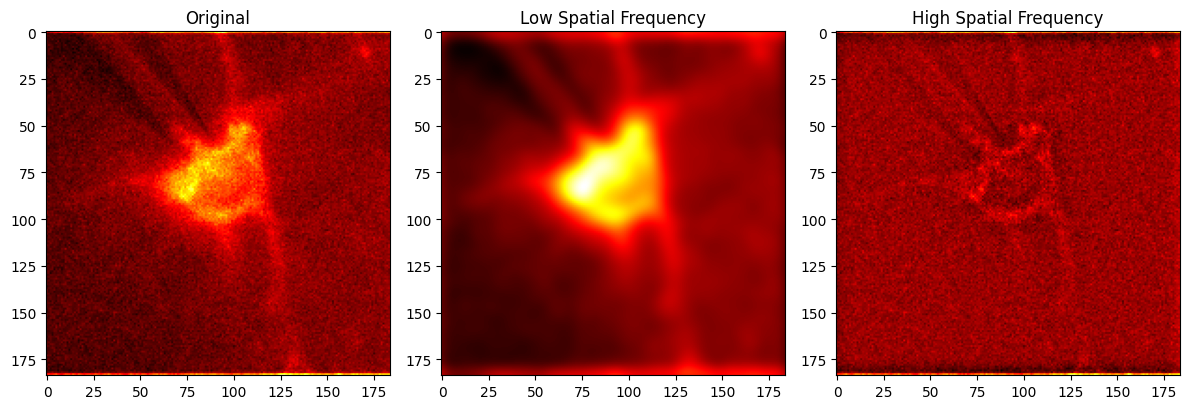

In [ ]:
import numpy as np
from scipy.fft import fft2, ifft2, fftshift, ifftshift

def lpgauss(H, W, sigma):
    """
    Create a 2D Gaussian low-pass filter in the frequency domain.
    Equivalent to the MATLAB lpgauss function.
    """
    kcx = sigma
    kcy = (H / W) * sigma

    x = np.arange(-W//2, W//2 + (W % 2))
    y = np.arange(-H//2, H//2 + (H % 2))
    X, Y = np.meshgrid(x, y)

    temp = -(X**2 / kcx**2 + Y**2 / kcy**2)
    out = ifftshift(np.exp(temp))  # Shift to match FFT layout

    return out

def hpgauss(H, W, sigma):
    """
    Create a 2D Gaussian high-pass filter in the frequency domain.
    Equivalent to MATLAB's hpgauss = 1 - lpgauss
    """
    return 1.0 - lpgauss(H, W, sigma)

def apply_frequency_filter(image, filter_kernel):
    """
    Applies a frequency domain filter to a 2D image.
    """
    F = fft2(image)
    F_filtered = F * filter_kernel
    return np.real(ifft2(F_filtered))

image = vol_data[100]  # shape: (H, W), single frame or spatial slice
H, W = image.shape
sigma = 12  # Tune based on desired cutoff frequency

lp_filter = lpgauss(H, W, sigma)
hp_filter = hpgauss(H, W, sigma)

low_pass_img = apply_frequency_filter(image, lp_filter)
high_pass_img = apply_frequency_filter(image, hp_filter)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='hot')
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(low_pass_img, cmap='hot')
plt.title('Low Spatial Frequency')
plt.subplot(1, 3, 3)
plt.imshow(high_pass_img, cmap='hot')
plt.title('High Spatial Frequency')
plt.tight_layout()
plt.show()